# Notebook 04 — Comparación de Modelos Candidatos

Proyecto: Clasificación de ensayos EEG [match vs mismatch].  
Track elegido: Track A - ML Clásico  
Autores: Jose Pablo Agüero Mora, Roilin Navarro Vargas

# Objetivo

En este notebook se comparan varios modelos de aprendizaje supervisado usando la matriz de features construida en el Notebook 02. La idea es evaluar un grupo pequeño de familias de modelos bajo el mismo protocolo experimental (validación cruzada por sujeto con GroupKFold) y seleccionar un candidato para el ajuste fino del Notebook 05.

Se usan modelos lineales, no lineales y de ensamble: regresión logística (L2), SVM con kernel RBF, random forest, XGBoost y LightGBM. Para evitar fuga de información entre folds, cualquier transformación (por ejemplo StandardScaler) se aplica dentro del pipeline y se ajusta únicamente con los datos del fold de entrenamiento. Para el desbalance de clases se usan pesos por clase cuando aplica y, en el caso de XGBoost, se usa scale_pos_weight.

## 1. Configuración

In [1]:
PROJECT_ROOT_DRIVE = '/content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400'
FORCE_RERUN = False

print(f'PROJECT_ROOT_DRIVE: {PROJECT_ROOT_DRIVE}')
print(f'FORCE_RERUN:        {FORCE_RERUN}')

PROJECT_ROOT_DRIVE: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400
FORCE_RERUN:        False


## 2. Instalación

In [2]:
%%capture
!pip install -q --upgrade --no-cache-dir "shap>=0.46.0"
!pip install -q mne==1.12.1
!pip install -q scikit-learn xgboost lightgbm optuna
!pip install -q pyxdf openpyxl pyyaml tqdm jedi

In [ ]:
import os
os.kill(os.getpid(), 9)

## 3. Imports

In [4]:
import os
import sys
import json
import yaml
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, confusion_matrix, roc_curve
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print(f'Python:       {sys.version.split()[0]}')
print(f'NumPy:        {np.__version__}')
print(f'scikit-learn: {__import__("sklearn").__version__}')
print(f'XGBoost:      {__import__("xgboost").__version__}')
print(f'LightGBM:     {__import__("lightgbm").__version__}')

Python:       3.12.13
NumPy:        2.0.2
scikit-learn: 1.6.1
XGBoost:      3.2.0
LightGBM:     4.6.0


## 4. Drive + configuración

In [5]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

CONFIG_PATH = Path(PROJECT_ROOT_DRIVE) / 'configs' / 'main_config.yaml'
with open(CONFIG_PATH, 'r') as f:
    CFG = yaml.safe_load(f)

SEED = CFG['seed']
random.seed(SEED)
np.random.seed(SEED)

REPORTS_DIR  = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['reports_dir']
FIGURES_DIR  = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['figures_dir']
FEATURES_DIR = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['features_dir']
MODELS_DIR   = Path(PROJECT_ROOT_DRIVE) / CFG['paths']['models_dir']

print(f' Config cargada (seed = {SEED})')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Config cargada (seed = 42)


## 5. Cargar matriz de features y holdout split

In [6]:
# Features
df = pd.read_csv(FEATURES_DIR / '02_features_matrix.csv')
feature_cols = [c for c in df.columns if c not in ['subject_id', 'epoch_idx', 'condition', 'label']]

# Holdout split persistente
with open(MODELS_DIR / 'holdout_split.json', 'r') as f:
    split_info = json.load(f)

# Filtrar al conjunto de CV (excluye los 5 sujetos de holdout)
df_cv = df[df['subject_id'].isin(split_info['cv_subjects'])].reset_index(drop=True)
X_cv = df_cv[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0).values
y_cv = df_cv['label'].values
groups_cv = df_cv['subject_id'].values

# Verificación anti-leakage
intersection = set(df_cv['subject_id']) & set(split_info['holdout_subjects'])
assert len(intersection) == 0, '¡LEAKAGE!'

print(f' Dataset de CV: {X_cv.shape[0]} epochs × {X_cv.shape[1]} features')
print(f'  Sujetos: {len(np.unique(groups_cv))} (de 29; 5 reservados para holdout)')
print(f'  match: {sum(y_cv==0)}  ({100*sum(y_cv==0)/len(y_cv):.1f}%)')
print(f'  mismatch: {sum(y_cv==1)}  ({100*sum(y_cv==1)/len(y_cv):.1f}%)')
print(f'\n Anti-leakage verificado')

 Dataset de CV: 1238 epochs × 72 features
  Sujetos: 24 (de 29; 5 reservados para holdout)
  match: 709  (57.3%)
  mismatch: 529  (42.7%)

 Anti-leakage verificado


## 6. Funciones de evaluación (mismas del Notebook 03)

In [7]:
def bootstrap_ci(y_true, y_pred, metric_fn, n_iter=1000, ci=0.95, seed=SEED):
    """Bootstrap CI de una métrica."""
    n = len(y_true)
    rng = np.random.default_rng(seed)
    scores = []
    for _ in range(n_iter):
        idx = rng.integers(0, n, n)
        try:
            scores.append(metric_fn(y_true[idx], y_pred[idx]))
        except Exception:
            continue
    lo = float(np.percentile(scores, (1 - ci) / 2 * 100))
    hi = float(np.percentile(scores, (1 + ci) / 2 * 100))
    return float(np.mean(scores)), lo, hi


def evaluate_cv(pipeline, X, y, groups, cv_n_splits=5, name='model', n_boot=1000):
    """Cross-validation con GroupKFold + métricas + bootstrap CI."""
    gkf = GroupKFold(n_splits=cv_n_splits)
    t0 = time.time()
    y_pred = cross_val_predict(pipeline, X, y, groups=groups, cv=gkf, n_jobs=1)
    try:
        y_proba = cross_val_predict(pipeline, X, y, groups=groups, cv=gkf, method='predict_proba', n_jobs=1)[:, 1]
    except (AttributeError, ValueError):
        y_proba = None
    elapsed = time.time() - t0

    acc_m, acc_lo, acc_hi = bootstrap_ci(y, y_pred, lambda a, b: accuracy_score(a, b), n_iter=n_boot)
    f1m_m, f1m_lo, f1m_hi = bootstrap_ci(y, y_pred, lambda a, b: f1_score(a, b, average='macro'), n_iter=n_boot)
    pre_m, pre_lo, pre_hi = bootstrap_ci(y, y_pred, lambda a, b: precision_score(a, b, average='macro', zero_division=0), n_iter=n_boot)
    rec_m, rec_lo, rec_hi = bootstrap_ci(y, y_pred, lambda a, b: recall_score(a, b, average='macro', zero_division=0), n_iter=n_boot)

    if y_proba is not None:
        auc_m, auc_lo, auc_hi = bootstrap_ci(y, y_proba, lambda a, b: roc_auc_score(a, b), n_iter=n_boot)
    else:
        auc_m = auc_lo = auc_hi = np.nan

    return {
        'name': name,
        'elapsed_sec':     elapsed,
        'accuracy':        acc_m,  'accuracy_lo':  acc_lo, 'accuracy_hi':  acc_hi,
        'f1_macro':        f1m_m,  'f1_macro_lo':  f1m_lo, 'f1_macro_hi':  f1m_hi,
        'precision_macro': pre_m,  'precision_lo': pre_lo, 'precision_hi': pre_hi,
        'recall_macro':    rec_m,  'recall_lo':    rec_lo, 'recall_hi':    rec_hi,
        'roc_auc':         auc_m,  'roc_auc_lo':   auc_lo, 'roc_auc_hi':   auc_hi,
        'y_pred':  y_pred,
        'y_proba': y_proba,
        'y_true':  y,
    }

print(' Funciones de evaluación definidas')

 Funciones de evaluación definidas


## 7. Definición de modelos candidatos

Se definen cinco modelos con hiperparámetros base (sin tuning). La intención es comparar familias, no exprimir el máximo rendimiento todavía.

Como la distribución de clases no es perfectamente 50/50, se utiliza class_weight='balanced' en los modelos de scikit-learn cuando está disponible. En XGBoost se usa scale_pos_weight calculado como n_neg/n_pos para compensar la diferencia entre clases.

In [8]:
# Calcular scale_pos_weight para XGBoost
n_neg = sum(y_cv == 0)
n_pos = sum(y_cv == 1)
scale_pos_weight = n_neg / n_pos
print(f'Para XGBoost: scale_pos_weight = {n_neg}/{n_pos} = {scale_pos_weight:.3f}')

# Diccionario de modelos
models = {
    'LogisticRegression_L2': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            penalty='l2', C=1.0,
            class_weight='balanced',
            max_iter=2000,
            random_state=SEED
        ))
    ]),
    'SVM_RBF': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(
            kernel='rbf', C=1.0, gamma='scale',
            class_weight='balanced',
            probability=True,            # necesario para AUC
            random_state=SEED
        ))
    ]),
    'RandomForest': Pipeline([
        ('scaler', StandardScaler()),    # no necesario para RF, pero mantenemos consistencia
        ('clf', RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_split=2,
            class_weight='balanced',
            n_jobs=-1,
            random_state=SEED
        ))
    ]),
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.1,
            scale_pos_weight=scale_pos_weight,
            eval_metric='logloss',
            tree_method='hist',
            n_jobs=-1,
            random_state=SEED,
            verbosity=0
        ))
    ]),
    'LightGBM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LGBMClassifier(
            n_estimators=200,
            max_depth=-1,
            num_leaves=31,
            learning_rate=0.1,
            class_weight='balanced',
            n_jobs=-1,
            random_state=SEED,
            verbosity=-1
        ))
    ]),
}

print(f'\n {len(models)} modelos definidos:')
for name in models:
    print(f'  - {name}')

Para XGBoost: scale_pos_weight = 709/529 = 1.340

 5 modelos definidos:
  - LogisticRegression_L2
  - SVM_RBF
  - RandomForest
  - XGBoost
  - LightGBM


## 8. Evaluación de modelos

Cada modelo se evalúa con GroupKFold (grupos por subject_id). Esto mantiene separadas las epochs de un mismo sujeto entre folds y reduce el riesgo de fuga de información.

Aquí el tiempo de ejecución varía según el modelo. En particular, SVM con probability=True suele tardar más (porque necesita pasos adicionales para producir probabilidades).

In [9]:
results_path = REPORTS_DIR / '04_models_cv_comparison.csv'
models_results = {}

for name, pipeline in tqdm(models.items(), desc='Evaluando modelos'):
    print(f'\n--- Evaluando {name} ---')
    r = evaluate_cv(
        pipeline=pipeline,
        X=X_cv, y=y_cv, groups=groups_cv,
        cv_n_splits=CFG['splits']['cv_n_splits'],
        name=name,
        n_boot=CFG['metrics']['bootstrap_n_iterations']
    )
    models_results[name] = r
    print(f'  tiempo CV:  {r["elapsed_sec"]:.1f} s')
    print(f'  Accuracy:   {r["accuracy"]:.3f}  [{r["accuracy_lo"]:.3f}, {r["accuracy_hi"]:.3f}]')
    print(f'  Macro F1:   {r["f1_macro"]:.3f}  [{r["f1_macro_lo"]:.3f}, {r["f1_macro_hi"]:.3f}]')
    print(f'  ROC-AUC:    {r["roc_auc"]:.3f}  [{r["roc_auc_lo"]:.3f}, {r["roc_auc_hi"]:.3f}]')

Evaluando modelos:   0%|          | 0/5 [00:00<?, ?it/s]


--- Evaluando LogisticRegression_L2 ---
  tiempo CV:  0.4 s
  Accuracy:   0.529  [0.502, 0.558]
  Macro F1:   0.520  [0.494, 0.549]
  ROC-AUC:    0.515  [0.484, 0.549]

--- Evaluando SVM_RBF ---
  tiempo CV:  4.2 s
  Accuracy:   0.529  [0.503, 0.558]
  Macro F1:   0.510  [0.484, 0.538]
  ROC-AUC:    0.528  [0.497, 0.560]

--- Evaluando RandomForest ---
  tiempo CV:  26.9 s
  Accuracy:   0.547  [0.519, 0.573]
  Macro F1:   0.446  [0.421, 0.473]
  ROC-AUC:    0.516  [0.485, 0.550]

--- Evaluando XGBoost ---
  tiempo CV:  25.1 s
  Accuracy:   0.517  [0.490, 0.545]
  Macro F1:   0.495  [0.469, 0.522]
  ROC-AUC:    0.509  [0.478, 0.541]

--- Evaluando LightGBM ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

  tiempo CV:  28.9 s
  Accuracy:   0.543  [0.515, 0.571]
  Macro F1:   0.518  [0.491, 0.545]
  ROC-AUC:    0.527  [0.496, 0.559]


## 9. Tabla comparativa

Resumen con todos los modelos y sus intervalos de confianza.

In [10]:
rows = []
for name, r in models_results.items():
    rows.append({
        'modelo':          name,
        'accuracy':        r['accuracy'],
        'accuracy_lo':     r['accuracy_lo'],
        'accuracy_hi':     r['accuracy_hi'],
        'f1_macro':        r['f1_macro'],
        'f1_macro_lo':     r['f1_macro_lo'],
        'f1_macro_hi':     r['f1_macro_hi'],
        'precision_macro': r['precision_macro'],
        'recall_macro':    r['recall_macro'],
        'roc_auc':         r['roc_auc'],
        'roc_auc_lo':      r['roc_auc_lo'],
        'roc_auc_hi':      r['roc_auc_hi'],
        'elapsed_sec':     r['elapsed_sec'],
    })
df_models = pd.DataFrame(rows).sort_values('f1_macro', ascending=False).reset_index(drop=True)
df_models.to_csv(REPORTS_DIR / '04_models_cv_comparison.csv', index=False)

# Versión visual con CI
display_rows = []
for _, row in df_models.iterrows():
    display_rows.append({
        'modelo':        row['modelo'],
        'accuracy':      f'{row["accuracy"]:.3f} [{row["accuracy_lo"]:.3f}, {row["accuracy_hi"]:.3f}]',
        'macro_F1':      f'{row["f1_macro"]:.3f} [{row["f1_macro_lo"]:.3f}, {row["f1_macro_hi"]:.3f}]',
        'roc_auc':       f'{row["roc_auc"]:.3f} [{row["roc_auc_lo"]:.3f}, {row["roc_auc_hi"]:.3f}]',
        'tiempo_CV (s)': f'{row["elapsed_sec"]:.1f}',
    })

print('=== COMPARACIÓN DE MODELOS (CV con GroupKFold k=5, ordenado por Macro F1) ===\n')
print(pd.DataFrame(display_rows).to_string(index=False))
print(f'\n Guardado: reports/04_models_cv_comparison.csv')

=== COMPARACIÓN DE MODELOS (CV con GroupKFold k=5, ordenado por Macro F1) ===

               modelo             accuracy             macro_F1              roc_auc tiempo_CV (s)
LogisticRegression_L2 0.529 [0.502, 0.558] 0.520 [0.494, 0.549] 0.515 [0.484, 0.549]           0.4
             LightGBM 0.543 [0.515, 0.571] 0.518 [0.491, 0.545] 0.527 [0.496, 0.559]          28.9
              SVM_RBF 0.529 [0.503, 0.558] 0.510 [0.484, 0.538] 0.528 [0.497, 0.560]           4.2
              XGBoost 0.517 [0.490, 0.545] 0.495 [0.469, 0.522] 0.509 [0.478, 0.541]          25.1
         RandomForest 0.547 [0.519, 0.573] 0.446 [0.421, 0.473] 0.516 [0.485, 0.550]          26.9

 Guardado: reports/04_models_cv_comparison.csv


## 10. Comparación con baselines del Notebook 03

In [13]:
baselines_path = REPORTS_DIR / '03_baselines_results.csv'
df_baselines = pd.read_csv(baselines_path)

# Combinar baselines y modelos
combined_rows = []
for _, row in df_baselines.iterrows():
    combined_rows.append({
        'tipo':       'baseline',
        'modelo':     row['modelo'],
        'f1_macro':   row['f1_macro'],
        'f1_macro_lo': row['f1_macro_lo'],
        'f1_macro_hi': row['f1_macro_hi'],
    })
for _, row in df_models.iterrows():
    combined_rows.append({
        'tipo':       'candidato',
        'modelo':     row['modelo'],
        'f1_macro':   row['f1_macro'],
        'f1_macro_lo': row['f1_macro_lo'],
        'f1_macro_hi': row['f1_macro_hi'],
    })
df_combined = pd.DataFrame(combined_rows).sort_values('f1_macro').reset_index(drop=True)

# Best baseline para comparar
best_baseline_f1 = df_baselines['f1_macro'].max()
best_baseline_name = df_baselines.loc[df_baselines['f1_macro'].idxmax(), 'modelo']
print(f'Mejor baseline:  {best_baseline_name}  -  Macro F1 = {best_baseline_f1:.3f}')
print(f'Umbral mínimo para que el modelo principal aporte valor: {best_baseline_f1 + 0.03:.3f}')

# Cuántos candidatos superan el umbral
winners = df_models[df_models['f1_macro'] > best_baseline_f1 + 0.03]
print(f'\nModelos que superan el umbral: {len(winners)} de {len(df_models)}')
if len(winners) > 0:
    print('Ganadores:')
    for _, row in winners.iterrows():
        print(f'  - {row["modelo"]:25s}  Macro F1 = {row["f1_macro"]:.3f}')

Mejor baseline:  Heurístico ERP extendido (De las 4 features)  -  Macro F1 = 0.516
Umbral mínimo para que el modelo principal aporte valor: 0.546

Modelos que superan el umbral: 0 de 5


## 11. Visualizaciones

### 11.1 Comparación visual de Macro F1 con CI

 Guardado: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/figures/04_models_vs_baselines.png


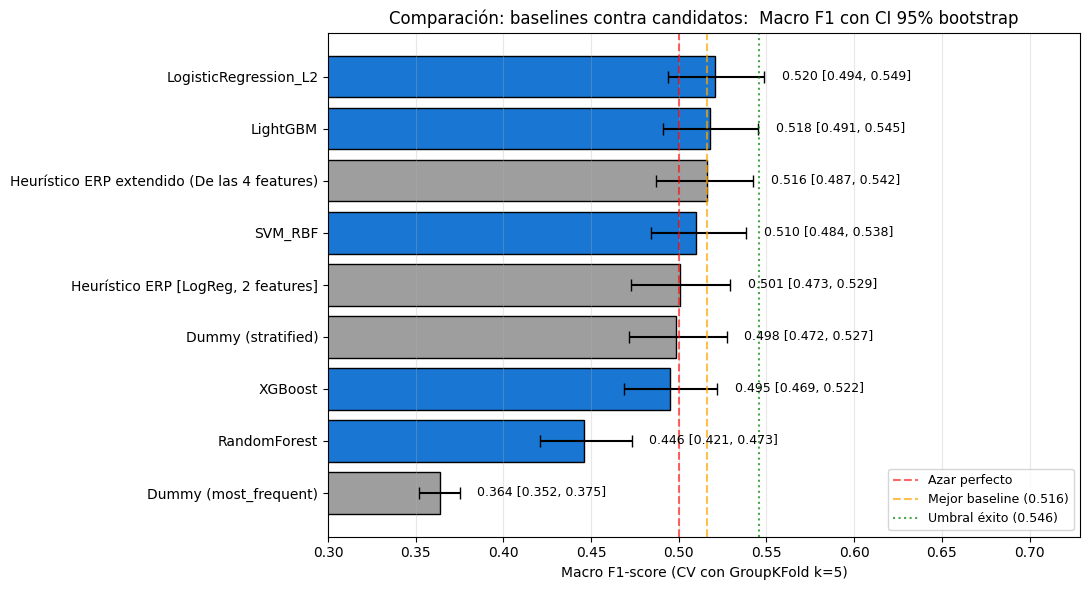

In [14]:
fig, ax = plt.subplots(figsize=(11, 6))

colors = ['#9e9e9e' if t == 'baseline' else '#1976d2' for t in df_combined['tipo']]

means = df_combined['f1_macro'].values
los   = df_combined['f1_macro_lo'].values
his   = df_combined['f1_macro_hi'].values
names = df_combined['modelo'].values

y_pos = np.arange(len(names))
ax.barh(y_pos, means,
        xerr=[means - los, his - means],
        color=colors, capsize=4, edgecolor='black')
ax.set_yticks(y_pos)
ax.set_yticklabels(names)
ax.axvline(0.5, color='red', linestyle='--', alpha=0.6, label='Azar perfecto')
ax.axvline(best_baseline_f1, color='orange', linestyle='--', alpha=0.7,
           label=f'Mejor baseline ({best_baseline_f1:.3f})')
ax.axvline(best_baseline_f1 + 0.03, color='green', linestyle=':', alpha=0.7,
           label=f'Umbral éxito ({best_baseline_f1+0.03:.3f})')

for i, (m, lo, hi) in enumerate(zip(means, los, his)):
    ax.text(hi + 0.01, i, f'{m:.3f} [{lo:.3f}, {hi:.3f}]', va='center', fontsize=9)

ax.set_xlabel('Macro F1-score (CV con GroupKFold k=5)')
ax.set_xlim(0.3, max(his) + 0.18)
ax.set_title('Comparación: baselines contra candidatos:  Macro F1 con CI 95% bootstrap', fontsize=12)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
fig_path = FIGURES_DIR / '04_models_vs_baselines.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
print(f' Guardado: {fig_path}')
plt.show()

### 11.2 Matrices de confusión de los 5 candidatos

 Guardado: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/figures/04_models_confusion_matrices.png


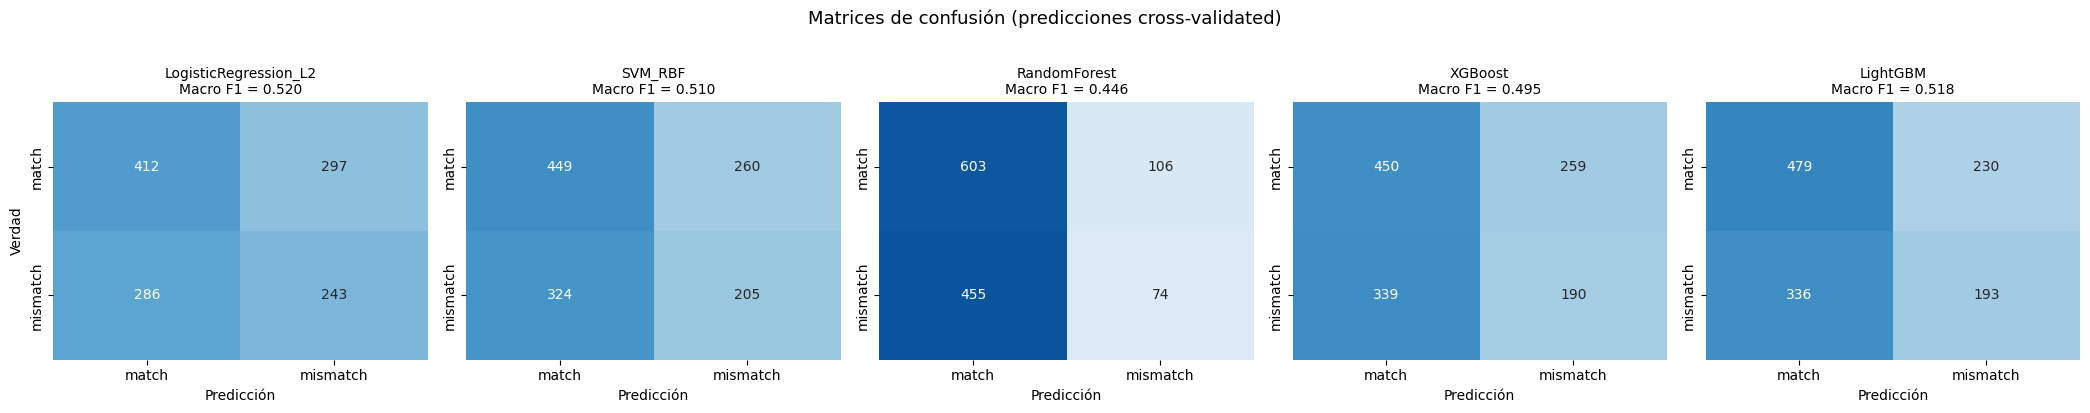

In [15]:
n_models = len(models_results)
fig, axes = plt.subplots(1, n_models, figsize=(4.2 * n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (name, r) in zip(axes, models_results.items()):
    cm = confusion_matrix(r['y_true'], r['y_pred'])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['match', 'mismatch'], yticklabels=['match', 'mismatch'],
                ax=ax, vmin=0, vmax=1)
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Verdad' if ax is axes[0] else '')
    ax.set_title(f'{name}\nMacro F1 = {r["f1_macro"]:.3f}', fontsize=10)

plt.suptitle('Matrices de confusión (predicciones cross-validated)', fontsize=13, y=1.02)
plt.tight_layout()
fig_path = FIGURES_DIR / '04_models_confusion_matrices.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
print(f' Guardado: {fig_path}')
plt.show()

### 11.3 Curvas ROC superpuestas

 Guardado: /content/drive/MyDrive/IA_Proyecto_EEG/proyecto-eeg-n400/figures/04_models_roc_curves.png


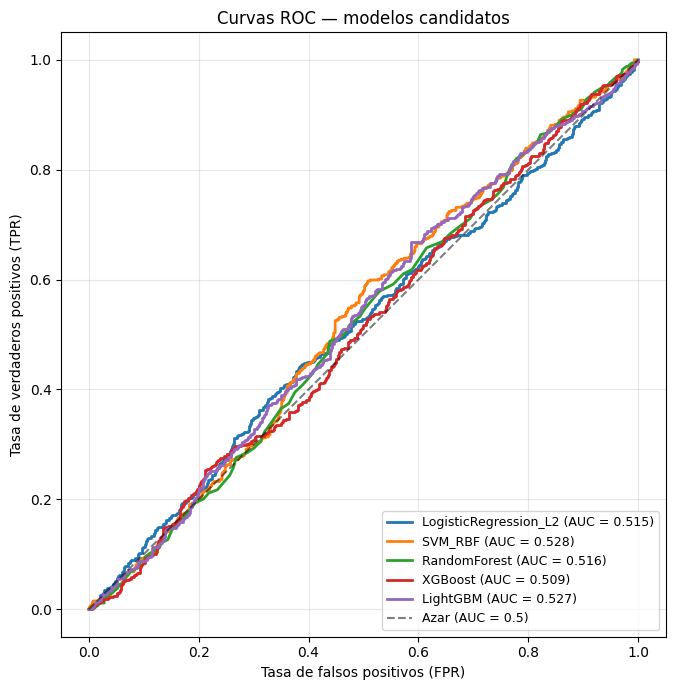

In [16]:
fig, ax = plt.subplots(figsize=(7, 7))

for name, r in models_results.items():
    if r['y_proba'] is None:
        continue
    fpr, tpr, _ = roc_curve(r['y_true'], r['y_proba'])
    ax.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {r["roc_auc"]:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Azar (AUC = 0.5)')
ax.set_xlabel('Tasa de falsos positivos (FPR)')
ax.set_ylabel('Tasa de verdaderos positivos (TPR)')
ax.set_title('Curvas ROC — modelos candidatos', fontsize=12)
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
fig_path = FIGURES_DIR / '04_models_roc_curves.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
print(f' Guardado: {fig_path}')
plt.show()

## 12. Selección del modelo

La selección se hace con base en el macro F1 promedio en validación cruzada. Si dos modelos quedan muy cercanos, se toma en cuenta también el tiempo de ejecución y la simplicidad del modelo, ya que el objetivo en este punto es escoger una familia razonable para ajustar para el Notebook 05.

In [17]:
# Modelo ganador: el de mejor Macro F1
winner_row = df_models.iloc[0]
winner_name = winner_row['modelo']

print(f'=== MODELO GANADOR ===')
print(f'Nombre:    {winner_name}')
print(f'Macro F1:  {winner_row["f1_macro"]:.3f}  [{winner_row["f1_macro_lo"]:.3f}, {winner_row["f1_macro_hi"]:.3f}]')
print(f'Accuracy:  {winner_row["accuracy"]:.3f}  [{winner_row["accuracy_lo"]:.3f}, {winner_row["accuracy_hi"]:.3f}]')
print(f'ROC-AUC:   {winner_row["roc_auc"]:.3f}  [{winner_row["roc_auc_lo"]:.3f}, {winner_row["roc_auc_hi"]:.3f}]')
print(f'Tiempo:    {winner_row["elapsed_sec"]:.1f} s en CV')

improvement_vs_baseline = winner_row['f1_macro'] - best_baseline_f1
print(f"\nComparación contra el mejor baseline ({best_baseline_name})")
print(f"Diferencia en Macro F1: {improvement_vs_baseline:+.3f}")
if improvement_vs_baseline > 0.03:
    print('   El modelo aporta valor sobre los baselines ( > 0.03).')
elif improvement_vs_baseline > 0:
    print('   Mejora marginal. Hay que analizar si vale la pena el tuning.')
else:
    print('   El modelo NO supera al baseline. Diagnosticar.')

# Guardar la decisión para el Notebook 05
decision = {
    'winner_model_name':     winner_name,
    'winner_f1_macro':       float(winner_row['f1_macro']),
    'winner_f1_macro_ci':    [float(winner_row['f1_macro_lo']), float(winner_row['f1_macro_hi'])],
    'best_baseline_name':    best_baseline_name,
    'best_baseline_f1':      float(best_baseline_f1),
    'improvement_over_baseline': float(improvement_vs_baseline),
    'ranking_by_f1_macro':   df_models[['modelo', 'f1_macro']].to_dict('records'),
}
with open(REPORTS_DIR / '04_best_model_selected.json', 'w') as f:
    json.dump(decision, f, indent=2)
print(f'\n Decisión guardada: reports/04_best_model_selected.json')

=== MODELO GANADOR ===
Nombre:    LogisticRegression_L2
Macro F1:  0.520  [0.494, 0.549]
Accuracy:  0.529  [0.502, 0.558]
ROC-AUC:   0.515  [0.484, 0.549]
Tiempo:    0.4 s en CV

Comparación contra el mejor baseline (Heurístico ERP extendido (De las 4 features))
Diferencia en Macro F1: +0.004
   Mejora marginal. Hay que analizar si vale la pena el tuning.

 Decisión guardada: reports/04_best_model_selected.json
